In [2]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

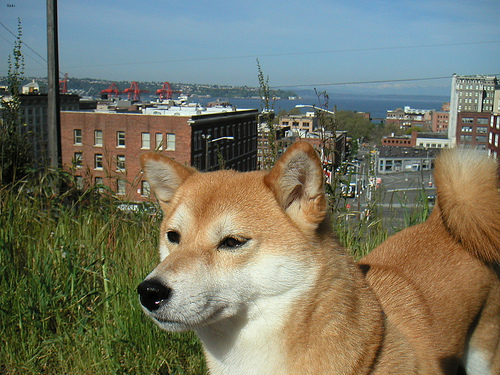

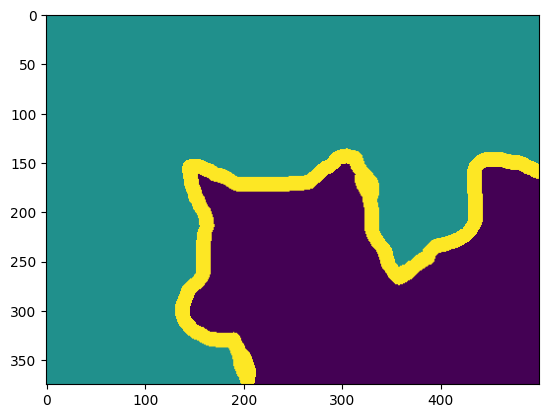

In [27]:
# grab a random doge with an xml
rng = np.random.default_rng(123)
doge_root = Path("doges")
doges = [f.stem for f in doge_root.glob("annotations/xmls/*.xml")]
doge = rng.choice(doges)

img = Image.open(doge_root / f"{doge}.jpg")
map = Image.open(doge_root / f"annotations/trimaps/{doge}.png")
plt.imshow(map)
img

In [ ]:
# load the xml data
import xml.etree.ElementTree as ET
etree = ET.parse(doge_root / f"annotations/xmls/{doge}.xml")

In [62]:
# Find the bounding box info
# XPath syntax is annoying, but .// means "find elements on all levels beneath the current"
bbox_e = etree.find(".//bndbox")

# store in a dictionary
bbox = {}
for child in bbox_e:
    bbox[child.tag] = int(child.text)

bbox

{'xmin': 137, 'ymin': 140, 'xmax': 328, 'ymax': 330}

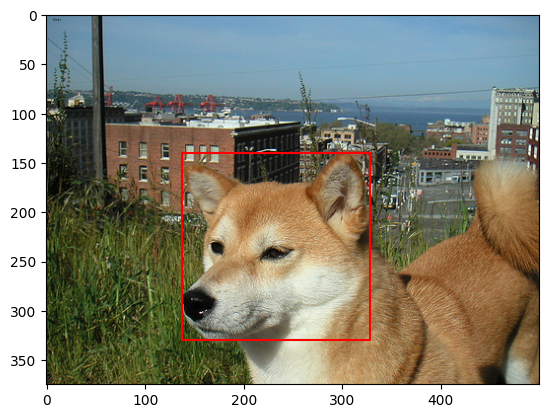

In [ ]:
# Draw the bounding box on the image
def plot_with_bbox(img, bbox):
    x = bbox["xmin"], bbox["xmin"], bbox["xmax"], bbox["xmax"], bbox["xmin"]
    y = bbox["ymin"], bbox["ymax"], bbox["ymax"], bbox["ymin"], bbox["ymin"]
    plt.imshow(img)
    plt.plot(x, y, "r")

plot_with_bbox(img, bbox)

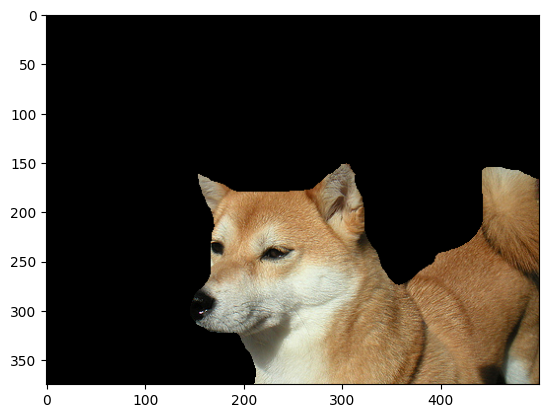

In [101]:
# multiply the image with the map foreground region
img_np = np.asarray(img)
map_np = np.asarray(map)
plt.imshow(img_np * np.expand_dims(map_np == 1, 2))

## Image Augmentations
